In [2]:
import pandas as pd

# on_bad_lines='skip' tells Python to ignore the broken rows and load the rest!
df = pd.read_excel('Cleaned New York Citi Bikes.xlsx')

# Let's see the data!
df.head()

,Start Time,Stop Time,Start Station ID,Start Station Name,End Station ID,End Station Name,Bike ID,User Type,Birth Year,Age,Age Groups,Trip Duration,Trip_Duration_in_min,Month,Season,Temperature,Weekday
0,2017-01-01 00:38:00,2017-01-01 01:03:00,3194,McGinley Square,3271,Danforth Light Rail,24668,Subscriber,1961,60,55-64,1513,25,1,Winter,10,Sunday
1,2017-01-01 01:47:00,2017-01-01 01:58:00,3183,Exchange Place,3203,Hamilton Park,26167,Subscriber,1993,28,25-34,639,11,1,Winter,10,Sunday
2,2017-01-01 01:47:00,2017-01-01 01:58:00,3183,Exchange Place,3203,Hamilton Park,26167,Subscriber,1993,28,25-34,639,11,1,Winter,10,Sunday
3,2017-01-01 01:56:00,2017-01-01 02:00:00,3186,Grove St PATH,3270,Jersey & 6th St,24604,Subscriber,1970,51,45-54,258,4,1,Winter,10,Sunday
4,2017-01-01 02:12:00,2017-01-01 02:23:00,3270,Jersey & 6th St,3206,Hilltop,24641,Subscriber,1978,43,35-44,663,11,1,Winter,10,Sunday


In [3]:
# Drop rows with missing data and drop exact duplicates
df = df.dropna()
df = df.drop_duplicates()

print("Blanks and duplicates removed successfully!")

Blanks and duplicates removed successfully!


In [4]:
# Convert to official datetime format
df['Start Time'] = pd.to_datetime(df['Start Time'])
df['Stop Time'] = pd.to_datetime(df['Stop Time'])

print("Time formatting fixed!")

Time formatting fixed!


In [5]:
# Strip invisible spaces
df['Start Station Name'] = df['Start Station Name'].str.strip()
df['End Station Name'] = df['End Station Name'].str.strip()

print("Station names cleaned!")

Station names cleaned!


In [6]:
# Keep only rows where Stop Time is after Start Time
df = df[df['Stop Time'] > df['Start Time']]

# Keep only rows where Trip Duration is greater than 0
df = df[df['Trip Duration'] > 0]

print("Logical errors filtered out! Your data is clean.")

Logical errors filtered out! Your data is clean.


In [7]:
# Export to a new CSV
df.to_csv('Cleaned_NYC_Bikes.csv', index=False)
print("Data saved as Cleaned_NYC_Bikes.csv")

Data saved as Cleaned_NYC_Bikes.csv


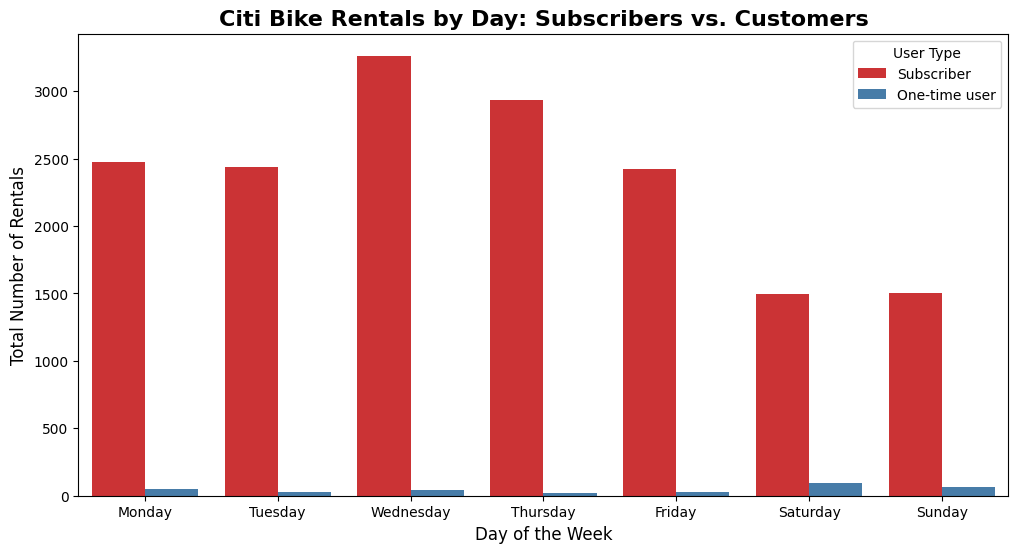

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Let's tell Python the correct order of the week so it doesn't do it alphabetically!
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# countplot automatically counts the rows. 'hue' splits it by User Type!
sns.countplot(data=df, x='Weekday', hue='User Type', order=day_order, palette='Set1')

# Add our professional titles
plt.title('Citi Bike Rentals by Day: Subscribers vs. Customers', fontsize=16, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Number of Rentals', fontsize=12)

# Make the legend look clean
plt.legend(title='User Type')

plt.show()

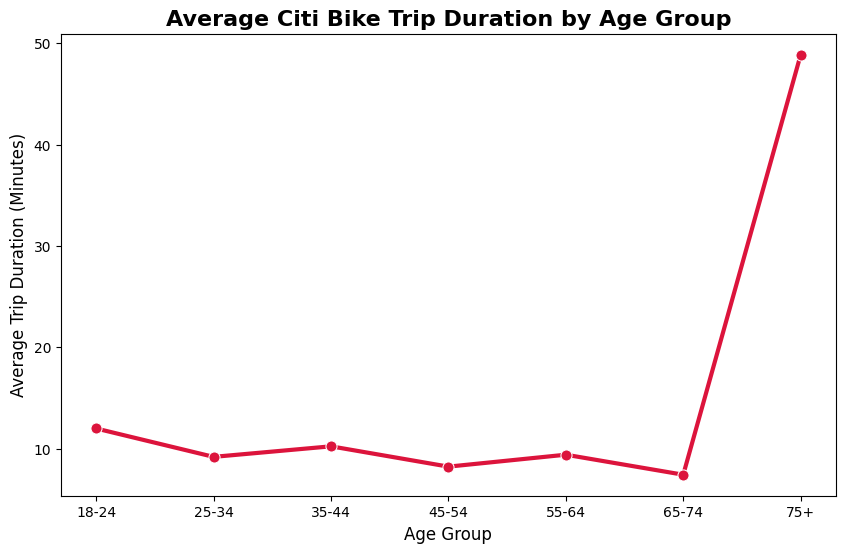

In [9]:
plt.figure(figsize=(10, 6))

# 1. Calculate the average duration just like a Pivot Table
avg_duration = df.groupby('Age Groups')['Trip_Duration_in_min'].mean().reset_index()

# 2. Draw the Line Chart
# marker='o' adds the little dots, linewidth makes the line thick and professional
sns.lineplot(data=avg_duration, x='Age Groups', y='Trip_Duration_in_min',
             marker='o', color='crimson', linewidth=3, markersize=8)

plt.title('Average Citi Bike Trip Duration by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Average Trip Duration (Minutes)', fontsize=12)

plt.show()

/tmp/ipykernel_6928/3364299715.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_stations, y='Station Name', x='Total Rentals', palette='viridis')


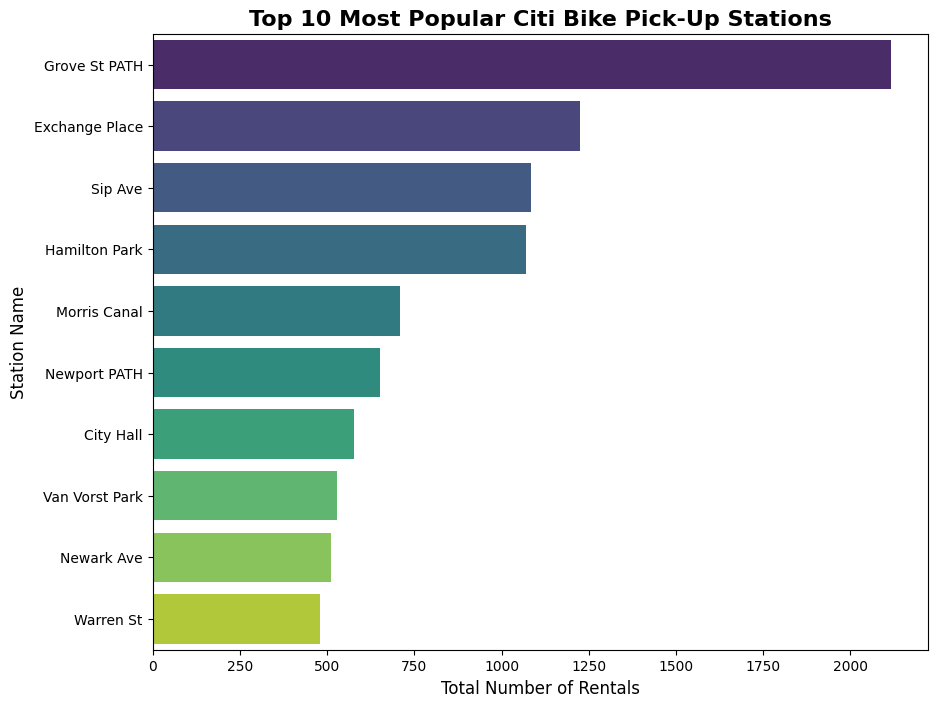

In [10]:
plt.figure(figsize=(10, 8))

# 1. Grab only the top 10 most popular stations
top_stations = df['Start Station Name'].value_counts().head(10).reset_index()
top_stations.columns = ['Station Name', 'Total Rentals']

# 2. Draw the Horizontal Bar Chart
# We use a cool color palette like 'viridis' to make it look sleek
sns.barplot(data=top_stations, y='Station Name', x='Total Rentals', palette='viridis')

plt.title('Top 10 Most Popular Citi Bike Pick-Up Stations', fontsize=16, fontweight='bold')
plt.xlabel('Total Number of Rentals', fontsize=12)
plt.ylabel('Station Name', fontsize=12)

plt.show()